<a href="https://colab.research.google.com/github/jashwanthnaiknenavath83-jpg/solar-project-finance-model-germany/blob/main/notebooks/02_smard_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1512/2636770792.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = d.groupby("year").apply(stats)
/tmp/ipykernel_1512/2636770792.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = d.groupby("month").apply(stats)


year                                        2024     2025
Baseload price (EUR/MWh)                  78.512   89.322
Solar capture price (EUR/MWh)             46.225   46.072
Capture rate                               0.589    0.516
Negative-price hours                     457.000  573.000
Share of solar output in negative hours    0.184    0.241


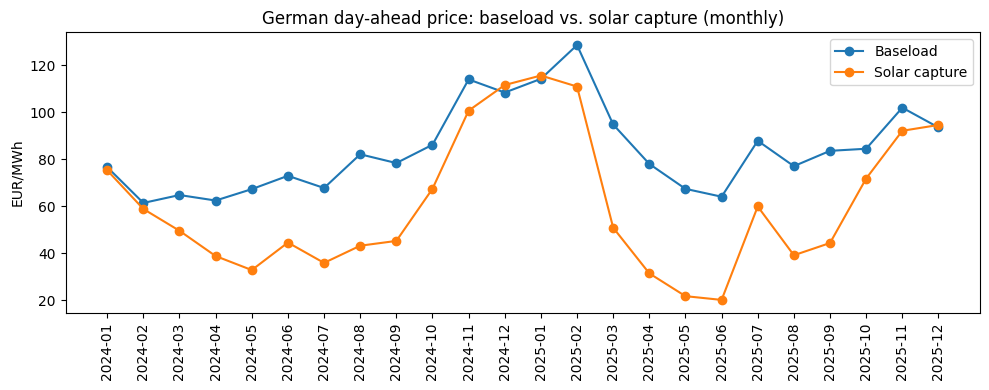

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

price_file = "Gro_handelspreise_202401010000_202601010000_Stunde.csv"
solar_file = "Realisierte_Erzeugung_202401010000_202601010000_Stunde.csv"

def read_smard(path):
    return pd.read_csv(path, sep=";", encoding="utf-8-sig")

def num(s):
    # SMARD uses "1.234,56" format; "-" means missing
    return pd.to_numeric(s.astype(str).str.replace(".", "", regex=False)
                           .str.replace(",", ".", regex=False), errors="coerce")

prices = read_smard(price_file)
gen = read_smard(solar_file)
assert len(prices) == len(gen)
assert (prices["Datum von"].values == gen["Datum von"].values).all()

price_col = [c for c in prices.columns if c.startswith("Deutschland/Luxemburg")][0]
solar_col = [c for c in gen.columns if c.startswith("Photovoltaik")][0]

d = pd.DataFrame({
    "time": pd.to_datetime(prices["Datum von"], format="%d.%m.%Y %H:%M"),
    "price": num(prices[price_col]),
    "solar": num(gen[solar_col]),
}).dropna()
d["year"] = d["time"].dt.year
d["month"] = d["time"].dt.to_period("M")

def stats(g):
    base = g["price"].mean()
    capture = (g["price"] * g["solar"]).sum() / g["solar"].sum()
    return pd.Series({
        "Baseload price (EUR/MWh)": base,
        "Solar capture price (EUR/MWh)": capture,
        "Capture rate": capture / base,
        "Negative-price hours": int((g["price"] < 0).sum()),
        "Share of solar output in negative hours": g["solar"][g["price"] < 0].sum() / g["solar"].sum(),
    })

yearly = d.groupby("year").apply(stats)
monthly = d.groupby("month").apply(stats)
print(yearly.round(3).T)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index.astype(str), monthly["Baseload price (EUR/MWh)"], marker="o", label="Baseload")
ax.plot(monthly.index.astype(str), monthly["Solar capture price (EUR/MWh)"], marker="o", label="Solar capture")
ax.set_title("German day-ahead price: baseload vs. solar capture (monthly)")
ax.set_ylabel("EUR/MWh")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()